In [1]:
# 1 — Imports & settings
import os
import math
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

print("OK: imports")


OK: imports


In [27]:
# 2 加载中文字体
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import os

# 1. 强制加载字体文件
font_path = r"C:\Windows\Fonts\msyh.ttc"
if not os.path.exists(font_path):
    font_path = r"C:\Windows\Fonts\simhei.ttf"

font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()

print("Loaded font:", font_name)

# 2. 写入 matplotlib 全局
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# 3. 写入 seaborn（这是你缺的）
sns.set_theme(
    style="white",
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

# 4. 让已经存在的 figure 也刷新
matplotlib.rcParams["font.family"] = font_name

Loaded font: Microsoft YaHei


In [2]:
# 3 — 读取你的两张原始 CSV
# =========================
# 1) Read raw CSVs
# =========================
amr_path = r"C:\Users\lunch\Downloads\amr_rate.csv"
x_path   = r"C:\Users\lunch\Downloads\climate_social_eco.csv"

amr = pd.read_csv(amr_path, encoding="utf-8-sig")
x   = pd.read_csv(x_path,   encoding="utf-8-sig")

print("AMR raw shape:", amr.shape)
print("X   raw shape:", x.shape)
amr.head()


AMR raw shape: (313, 15)
X   raw shape: (341, 31)


,Province,Year,MRCNS,VREFS,VREFM,PRSP,ERSP,3GCRKP,MRSA,3GCREC,CREC,QREC,CRPA,CRKP,CRAB
0,北京,2014,82.2,1.6,11.1,0.4,97.0,39.0,49.0,58.8,3.6,61.3,36.1,13.7,64.0
1,天津,2014,79.6,0.3,1.9,9.3,96.2,21.5,24.8,51.4,1.5,51.0,22.1,1.7,22.1
2,河北,2014,80.3,0.7,2.4,7.0,97.4,47.5,43.4,66.3,2.2,60.1,30.9,6.7,63.0
3,山西,2014,70.5,0.6,1.3,1.4,93.8,31.7,24.2,58.4,1.2,55.5,20.4,2.6,52.7
4,内蒙古,2014,76.3,0.7,1.4,9.1,95.8,26.1,28.9,55.6,0.6,65.4,20.2,1.9,51.5


In [3]:
# 4 — 统一面板键名：Province / Year
def normalize_key_cols(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {}
    for c in df.columns:
        cc = str(c).strip()
        ccl = cc.lower()
        if ccl in ["province", "prov", "省份"]:
            col_map[c] = "Province"
        if ccl in ["year", "yr", "年份", "year "]:
            col_map[c] = "Year"
    return df.rename(columns=col_map)

amr = normalize_key_cols(amr)
x   = normalize_key_cols(x)

assert "Province" in amr.columns and "Year" in amr.columns, "AMR表缺 Province/Year"
assert "Province" in x.columns   and "Year" in x.columns,   "X表缺 Province/Year"

amr["Province"] = amr["Province"].astype(str).str.strip()
x["Province"]   = x["Province"].astype(str).str.strip()

# Year 转 int（先 coerce）
amr["Year"] = pd.to_numeric(amr["Year"], errors="coerce")
x["Year"]   = pd.to_numeric(x["Year"], errors="coerce")

print("Keys normalized.")
print("AMR keys example:", amr[["Province","Year"]].head())
print("X   keys example:", x[["Province","Year"]].head())


Keys normalized.
AMR keys example:   Province  Year
0       北京  2014
1       天津  2014
2       河北  2014
3       山西  2014
4      内蒙古  2014
X   keys example:   Province  Year
0       北京  2014
1       天津  2014
2       河北  2014
3       山西  2014
4      内蒙古  2014


In [4]:
# 5 — 选择 9 个解释变量列
# =========================
# 2) Select X cols (with robust mapping)
# =========================
X_MAP = {
    "TA": "省平均气温",
    "PA": "省平均降水",
    "R1xday": "R1xday",
    "PM25": "PM2.5",
    "MED": "医疗水平",
    "GDP": "GDP",
    "WATER": "城市用水普及率",
    "WASTE": "生活垃圾无害化处理率",
    "AMC": "抗菌药物使用强度",
}

# 若x里存在英文缩写列名，则 rename 成中文列名
rename_map = {k: v for k, v in X_MAP.items() if k in x.columns and v not in x.columns}
x = x.rename(columns=rename_map)

# 最终使用这 9 个中文列名
X_cols_used = list(X_MAP.values())

missing_x = [c for c in X_cols_used if c not in x.columns]
if missing_x:
    raise KeyError(
        f"X表缺少这些列（按截图要求）：{missing_x}\n"
        f"当前x.columns示例：{list(x.columns)[:40]}"
    )

print("X cols used:", X_cols_used)
x[X_cols_used].head()


X cols used: ['省平均气温', '省平均降水', 'R1xday', 'PM2.5', '医疗水平', 'GDP', '城市用水普及率', '生活垃圾无害化处理率', '抗菌药物使用强度']


,省平均气温,省平均降水,R1xday,PM2.5,医疗水平,GDP,城市用水普及率,生活垃圾无害化处理率,抗菌药物使用强度
0,11.802834,459.925228,39.409802,5.74,99,23577.5,100.00,99.6,NaN
1,13.439358,445.971354,33.522428,13.95,56,10749.2,100.00,96.7,NaN
2,10.775661,439.600300,22.180385,179.77,48,25644.1,99.29,86.6,NaN
3,9.330009,533.038397,26.461773,150.68,57,12307.0,98.54,92.1,NaN
4,4.819860,286.822913,10.227644,102.15,62,12377.3,97.79,96.1,NaN


In [5]:
# 6 — 面板去重 + 合并
DEDUP_STRATEGY = "drop"   # "drop" or "mean"

def dedup_panel(df: pd.DataFrame, key=("Province","Year"), strategy="drop") -> pd.DataFrame:
    df = df.copy()
    df = df.dropna(subset=list(key))
    # 同一省同一年重复行处理
    dup = df.duplicated(subset=list(key), keep=False)
    if not dup.any():
        return df

    if strategy == "drop":
        # drop duplicates, keep first
        return df.drop_duplicates(subset=list(key), keep="first").copy()

    if strategy == "mean":
        # 数值列取平均，非数值列取first
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        other_cols = [c for c in df.columns if c not in num_cols]
        g = df.groupby(list(key), as_index=False)
        out = g[num_cols].mean()
        for c in other_cols:
            out[c] = g[c].first()[c].values
        return out

    raise ValueError("strategy must be 'drop' or 'mean'")

amr2 = dedup_panel(amr, strategy=DEDUP_STRATEGY)
x2   = dedup_panel(x,   strategy=DEDUP_STRATEGY)

df = amr2.merge(x2, on=["Province","Year"], how="inner", suffixes=("", "_X"))
df = df.dropna(subset=["Province","Year"]).copy()
df["Year"] = df["Year"].astype(int)

print("Merged df shape:", df.shape)
print("Years:", df["Year"].min(), df["Year"].max(), " unique:", df["Year"].nunique())
print("Provinces:", df["Province"].nunique())
df.head()


Merged df shape: (310, 44)
Years: 2014 2023  unique: 10
Provinces: 31


,Province,Year,MRCNS,VREFS,VREFM,PRSP,ERSP,3GCRKP,MRSA,3GCREC,CREC,QREC,CRPA,CRKP,CRAB,主要城市平均气温,主要城市降水量,主要城市日照时数,省平均气温,省平均降水,TA（°C）,PA（%）,R1xday,R5xday,二氧化硫,氮氧化物,PM2.5,可支配收入,食品消费量,文盲比例,GDP,建成区绿化覆盖率,医疗水平,生活垃圾无害化处理率,卫生程度\n（日污水处理能力）,城市用水普及率,饮用水\n供水综合生产能力(万立方米/日),人均日生活用水量(升),牲畜饲养\n-大牲畜年底头数,牲畜饲养\n-猪年底头数,牲畜饲养\n-羊年底头数,抗菌药物使用强度,Unnamed: 29,Unnamed: 30
0,北京,2014,82.2,1.6,11.1,0.4,97.0,39.0,49.0,58.8,3.6,61.3,36.1,13.7,64.0,14.1,461.5,2344.1,11.802834,459.925228,0.649418,-8.840281,39.409802,68.626410,7.89,15.10,5.74,44489,NaN,1.48,23577.5,49.1,99,99.6,442.0,100.00,2439.77,187.52,20.32,179.60,68.35,NaN,NaN,NaN
1,天津,2014,79.6,0.3,1.9,9.3,96.2,21.5,24.8,51.4,1.5,51.0,22.1,1.7,22.1,14.0,441.4,2265.6,13.439358,445.971354,0.668522,-12.685535,33.522428,64.648231,20.92,28.23,13.95,28832,NaN,2.35,10749.2,34.9,56,96.7,262.6,100.00,447.15,124.33,30.38,199.78,46.76,NaN,NaN,NaN
2,河北,2014,80.3,0.7,2.4,7.0,97.4,47.5,43.4,66.3,2.2,60.1,30.9,6.7,63.0,14.9,294.8,1585.4,10.775661,439.600300,0.622596,-7.823015,22.180385,39.758130,118.99,151.25,179.77,16647,NaN,3.14,25644.1,41.9,48,86.6,523.2,99.29,809.04,116.91,488.23,1915.45,1526.40,NaN,NaN,NaN
3,山西,2014,70.5,0.6,1.3,1.4,93.8,31.7,24.2,58.4,1.2,55.5,20.4,2.6,52.7,10.9,428.7,2513.5,9.330009,533.038397,0.350352,6.659371,26.461773,54.392163,120.82,106.99,150.68,16538,NaN,2.89,12307.0,40.1,57,92.1,208.5,98.54,453.65,114.59,123.87,514.74,922.74,NaN,NaN,NaN
4,内蒙古,2014,76.3,0.7,1.4,9.1,95.8,26.1,28.9,55.6,0.6,65.4,20.2,1.9,51.5,7.7,394.8,2517.2,4.819860,286.822913,0.530587,-1.619586,10.227644,23.507594,131.24,125.83,102.15,20559,NaN,4.66,12377.3,39.8,62,96.1,189.5,97.79,425.47,103.49,839.86,669.44,5569.28,NaN,NaN,NaN


In [6]:
# 7 — 构建 AMR_AGG 与 AMR_AGG_z
def to_float(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype(float)

def zscore(s: pd.Series) -> pd.Series:
    s = to_float(s)
    mu = np.nanmean(s.values)
    sd = np.nanstd(s.values, ddof=0)
    if not np.isfinite(sd) or sd == 0:
        return s * np.nan
    return (s - mu) / sd

# 如果你想“严格指定 13 个 AMR 列”，可以在这里填进去：
AMR_COLS = None  # e.g. ["AMR1","AMR2",...]

if AMR_COLS is None:
    # 自动检测：排除 Province/Year 与 9个X后，剩余能转成数值且非空比例较高的列
    exclude = set(["Province","Year"]) | set(X_cols_used)

    cand = [c for c in df.columns if c not in exclude]
    good = []
    for c in cand:
        s = pd.to_numeric(df[c], errors="coerce")
        non_na = s.notna().mean()
        # 阈值可调整；0.5 表示至少一半非空
        if non_na >= 0.5:
            good.append(c)

    AMR_COLS = good

print("Auto-detected AMR cols count:", len(AMR_COLS))
print("AMR cols preview:", AMR_COLS[:20])

# 计算 AMR_AGG（行均值）
df["AMR_AGG"] = df[AMR_COLS].apply(lambda r: np.nanmean(pd.to_numeric(r, errors="coerce")), axis=1)
df["AMR_AGG_z"] = zscore(df["AMR_AGG"])

# 只保留 AMR_AGG_z 非空
df = df.dropna(subset=["AMR_AGG_z"]).copy()

print("After AMR_AGG_z:", df.shape, "AMR_AGG_z non-null:", df["AMR_AGG_z"].notna().mean())
df[["Province","Year","AMR_AGG","AMR_AGG_z"]].head()


Auto-detected AMR cols count: 31
AMR cols preview: ['MRCNS', 'VREFS', 'VREFM', 'PRSP', 'ERSP', '3GCRKP', 'MRSA', '3GCREC', 'CREC', 'QREC', 'CRPA', 'CRKP', 'CRAB', '主要城市平均气温', '主要城市降水量', '主要城市日照时数', 'TA（°C）', 'PA（%）', 'R5xday', '二氧化硫']
After AMR_AGG_z: (310, 46) AMR_AGG_z non-null: 1.0


,Province,Year,AMR_AGG,AMR_AGG_z
0,北京,2014,1709.935518,1.154768
1,天津,2014,1106.214374,-0.272956
2,河北,2014,825.902257,-0.935859
3,山西,2014,752.523063,-1.109392
4,内蒙古,2014,1067.772953,-0.363865


In [7]:
# 8 — 对 9 个解释变量做 z-score

for c in X_cols_used:
    df[c] = to_float(df[c])

# 逐列 z-score（全样本标准化）
for c in X_cols_used:
    df[c + "_z"] = zscore(df[c])

Xz_cols = [c + "_z" for c in X_cols_used]

# 丢掉任何一个 Xz 缺失的观测（这一步会导致你只有 8 年）
df2 = df.dropna(subset=Xz_cols).copy()

print("Before dropna X:", df.shape, "After:", df2.shape)
print("Years unique:", sorted(df2["Year"].unique()))
print("Time periods:", df2["Year"].nunique(), "Entities:", df2["Province"].nunique())
df2[["Province","Year","AMR_AGG_z"] + Xz_cols].head()


Before dropna X: (310, 55) After: (239, 55)
Years unique: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023)]
Time periods: 8 Entities: 30


,Province,Year,AMR_AGG_z,省平均气温_z,省平均降水_z,R1xday_z,PM2.5_z,医疗水平_z,GDP_z,城市用水普及率_z,生活垃圾无害化处理率_z,抗菌药物使用强度_z
31,北京,2015,1.346971,-0.132750,-0.886645,-0.312636,-0.945899,2.024031,-0.189082,0.653405,-3.033850,1.225412
32,天津,2015,-0.149064,0.121173,-0.854601,0.121056,-0.778794,-0.839292,-0.765472,0.653405,-0.751278,-0.507824
33,河北,2015,-0.829325,-0.284949,-0.904365,-0.778439,4.024905,-1.411957,-0.162060,0.487647,-0.209373,-0.727185
34,山西,2015,-1.042111,-0.493198,-0.904634,-0.762248,3.612843,-0.902922,-0.721823,0.220175,-0.012316,0.080699
35,内蒙古,2015,-0.276547,-1.144973,-1.290522,-1.130347,1.755795,-0.457516,-0.682752,0.077021,0.069791,-0.182376


### **空间邻接（距离矩阵 → kNN → 邻接 W）**

In [8]:
# 9. 读取 GADM 省界 shapefile
# 指向你解压后的 .gpkg 文件
import geopandas as gpd
import fiona

gpkg_path = r"C:\Users\lunch\Downloads\gadm41_CHN.gpkg"

# 先看看有哪些层
print(fiona.listlayers(gpkg_path))



['ADM_ADM_0', 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3']


In [9]:
# 9.2 读 省级（ADM_1）
gdf = gpd.read_file(gpkg_path, layer="ADM_ADM_1")

print("Total features:", len(gdf))
print("Unique NAME_1:", gdf["NAME_1"].nunique())
print(sorted(gdf["NAME_1"].unique()))


Total features: 37
Unique NAME_1: 33
['Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu', 'Guangdong', 'Guangxi', 'Guizhou', 'Hainan', 'Hebei', 'Heilongjiang', 'Henan', 'Hong Kong', 'Hubei', 'Hunan', 'Jiangsu', 'Jiangxi', 'Jilin', 'Liaoning', 'Macau', 'Nei Mongol', 'Ningxia Hui', 'Qinghai', 'Shaanxi', 'Shandong', 'Shanghai', 'Shanxi', 'Sichuan', 'Tianjin', 'Xinjiang Uygur', 'Xizang', 'Yunnan', 'Zhejiang']


In [10]:
# 9.3 
NAME1_TO_PANEL = {
    "Anhui": "安徽",
    "Beijing": "北京",
    "Chongqing": "重庆",
    "Fujian": "福建",
    "Gansu": "甘肃",
    "Guangdong": "广东",
    "Guangxi": "广西",
    "Guizhou": "贵州",
    "Hainan": "海南",
    "Hebei": "河北",
    "Heilongjiang": "黑龙江",
    "Henan": "河南",
    "Hubei": "湖北",
    "Hunan": "湖南",
    "Jiangsu": "江苏",
    "Jiangxi": "江西",
    "Jilin": "吉林",
    "Liaoning": "辽宁",
    "Nei Mongol": "内蒙古",
    "Ningxia Hui": "宁夏",   # ← 这里一定会成功
    "Qinghai": "青海",
    "Shaanxi": "陕西",
    "Shandong": "山东",
    "Shanghai": "上海",
    "Shanxi": "山西",
    "Sichuan": "四川",
    "Tianjin": "天津",
    "Xinjiang Uygur": "新疆",
    "Xizang": "西藏",
    "Yunnan": "云南",
    "Zhejiang": "浙江"
}

gdf["Province"] = gdf["NAME_1"].map(NAME1_TO_PANEL)
gdf = gdf.dropna(subset=["Province"])

print(sorted(gdf["Province"].unique()))
print("Count:", gdf["Province"].nunique())


['上海', '云南', '内蒙古', '北京', '吉林', '四川', '天津', '宁夏', '安徽', '山东', '山西', '广东', '广西', '新疆', '江苏', '江西', '河北', '河南', '浙江', '海南', '湖北', '湖南', '甘肃', '福建', '西藏', '贵州', '辽宁', '重庆', '陕西', '青海', '黑龙江']
Count: 31


In [11]:
# === 9.x 让 GADM 省界严格对齐 df2 的 30 省，并且 dissolve 合并多块面 ===
import numpy as np
import geopandas as gpd
from sklearn.neighbors import NearestNeighbors

# 1) 面板省份（30个）——以 df2 为准
panel_provs = sorted(df2["Province"].astype(str).str.strip().unique())
print("panel provinces n =", len(panel_provs))

# 2) GADM：只保留这些省 + 合并同省多面（关键！）
gdf_use = gdf.copy()
gdf_use["Province"] = gdf_use["Province"].astype(str).str.strip()
gdf_use = gdf_use[gdf_use["Province"].isin(panel_provs)].copy()

# dissolve：把新疆/西藏这种多块面合并成一个省
gdf_use = gdf_use.dissolve(by="Province", as_index=False)

# 3) 按 panel 顺序重排（保证 prov_idx 对应）
gdf_use = gdf_use.set_index("Province").loc[panel_provs].reset_index()

print("gdf_use provinces n =", gdf_use["Province"].nunique())
assert gdf_use["Province"].nunique() == len(panel_provs)

# 4) 重新算 W（这次 n=30 一定对）
gdf_proj = gdf_use.to_crs(epsg=3857)
cent = gdf_proj.geometry.centroid
X = np.column_stack([cent.x.values, cent.y.values])

k = 4
nn = NearestNeighbors(n_neighbors=k+1, algorithm="ball_tree").fit(X)
dist, idx = nn.kneighbors(X)

n = len(panel_provs)
W = np.zeros((n, n), dtype=int)
for i in range(n):
    neigh = idx[i, 1:]   # 去掉自己
    W[i, neigh] = 1

# 无向化 + 对角线置0
W = np.maximum(W, W.T)
np.fill_diagonal(W, 0)

deg = W.sum(axis=1)
print("W shape:", W.shape)
print("neighbors min/mean/max:", int(deg.min()), float(deg.mean()), int(deg.max()))
print("isolated nodes:", np.where(deg == 0)[0])

# 行标准化（可用于 CAR/BYM）
Wr = W.astype(float)
row_sum = Wr.sum(axis=1, keepdims=True)
Wr = np.divide(Wr, row_sum, out=np.zeros_like(Wr), where=row_sum != 0)

# 保险检查
assert W.shape[0] == df2["Province"].nunique() == 30


panel provinces n = 30
gdf_use provinces n = 30
W shape: (30, 30)
neighbors min/mean/max: 4 5.266666666666667 8
isolated nodes: []


In [12]:
# 9.4 先对齐：以面板 df2 的 30 省为准
import numpy as np
import pandas as pd

# 面板省份顺序（非常重要：后面 W 的顺序必须跟 df2 一致）
provinces = sorted(df2["Province"].astype(str).str.strip().unique())
print("Panel provinces n =", len(provinces))
print(provinces)

# 只保留面板里有的省（会自动剔除西藏）
gdf30 = gdf[gdf["Province"].isin(provinces)].copy()

# 严格按面板顺序重排
gdf30 = gdf30.set_index("Province").loc[provinces].reset_index()

print("gdf30 provinces n =", gdf30["Province"].nunique())
print(gdf30["Province"].tolist()[:10], "...")


Panel provinces n = 30
['上海', '云南', '内蒙古', '北京', '吉林', '四川', '天津', '宁夏', '安徽', '山东', '山西', '广东', '广西', '新疆', '江苏', '江西', '河北', '河南', '浙江', '海南', '湖北', '湖南', '甘肃', '福建', '贵州', '辽宁', '重庆', '陕西', '青海', '黑龙江']
gdf30 provinces n = 30
['上海', '云南', '内蒙古', '北京', '吉林', '四川', '天津', '宁夏', '安徽', '山东'] ...


In [47]:
# # 9.5 计算距离矩阵（用省界质心），并构建 kNN 权重矩阵 W
# ##  注意：一定要先投影到米制坐标系，否则经纬度直接算距离会不准。
# import numpy as np
# import geopandas as gpd
# from sklearn.neighbors import NearestNeighbors

# # ✅ 关键：W 的顺序和维度一律以 gdf30 为准（30省，顺序已对齐 df2）
# provinces = gdf30["Province"].astype(str).str.strip().tolist()
# n = len(provinces)
# assert n == len(gdf30), "gdf30 行数和 provinces 不一致"

# # 1) 投影到米制（EPSG:3857）
# gdf30_proj = gdf30.to_crs(epsg=3857)

# # 2) 质心坐标
# cent = gdf30_proj.geometry.centroid
# X = np.column_stack([cent.x.values, cent.y.values])

# # 3) kNN
# k = 4
# nn = NearestNeighbors(n_neighbors=k+1, algorithm="ball_tree").fit(X)
# dist, idx = nn.kneighbors(X)

# # 4) 构 W（0/1 邻接）
# W = np.zeros((n, n), dtype=int)
# for i in range(n):
#     neigh = idx[i, 1:]      # 去掉自己
#     W[i, neigh] = 1

# # 5) 对称化（无向）
# W = np.maximum(W, W.T)
# np.fill_diagonal(W, 0)

# # 6) 检查
# deg = W.sum(axis=1)
# print("W shape:", W.shape)
# print("neighbors min/mean/max:", int(deg.min()), float(deg.mean()), int(deg.max()))
# print("isolated nodes:", np.where(deg==0)[0])

# # （可选）行标准化版本：Wr，每行和为1（CAR/空间滞后有时用得上）
# Wr = W.astype(float)
# row_sum = Wr.sum(axis=1, keepdims=True)
# Wr = np.divide(Wr, row_sum, out=np.zeros_like(Wr), where=row_sum!=0)


W shape: (32, 32)
neighbors min/mean/max: 4 5.25 8
isolated nodes: []


In [13]:
# “保险检查”（防止 df2 其实是 31）
print("df2 entities:", df2["Province"].nunique())
print("gdf30 entities:", gdf30["Province"].nunique())


df2 entities: 30
gdf30 entities: 30


In [15]:
# 检查
# ✅ 强制检查：W 必须是 30x30，且和 df2 的省份数一致
nprov = df2["Province"].nunique()
print("nprov(df2) =", nprov)
print("W shape =", W.shape)

assert W.shape == (nprov, nprov), f"W 维度不对：{W.shape}，但 nprov={nprov}"

nprov(df2) = 30
W shape = (30, 30)


In [16]:
# 10：把面板数据整理成“PyMC 能吃的格式”

# 10.1 生成索引
import numpy as np
import pandas as pd

# 省份索引（0–29，与 W 行列顺序一致）
prov_list = gdf30["Province"].tolist()
prov_to_idx = {p:i for i,p in enumerate(panel_provs)}
prov_idx = df2["Province"].map(prov_to_idx).to_numpy()
assert prov_idx.min() == 0 and prov_idx.max() == nprov - 1

# 年份索引（0–7）
years = sorted(df2["Year"].unique())
year_to_idx = {y: i for i, y in enumerate(years)}

# 添加索引列
df_bayes = df2.copy()
df_bayes["prov_idx"] = df_bayes["Province"].map(prov_to_idx)
df_bayes["year_idx"] = df_bayes["Year"].map(year_to_idx)

# 检查
assert df_bayes["prov_idx"].isna().sum() == 0
assert df_bayes["year_idx"].isna().sum() == 0

print("N obs:", len(df_bayes))
print("N provinces:", df_bayes["prov_idx"].nunique())
print("N years:", df_bayes["year_idx"].nunique())


N obs: 239
N provinces: 30
N years: 8


In [17]:
# 10.2 构造矩阵形式
# 因变量
y = df_bayes["AMR_AGG_z"].values

# 解释变量（9 个 z-score）
X_cols = [
    "省平均气温_z",
    "省平均降水_z",
    "R1xday_z",
    "PM2.5_z",
    "医疗水平_z",
    "GDP_z",
    "城市用水普及率_z",
    "生活垃圾无害化处理率_z",
    "抗菌药物使用强度_z",
]
X = df_bayes[X_cols].values

prov_idx = df_bayes["prov_idx"].values
year_idx = df_bayes["year_idx"].values

N, P = X.shape
print("X shape:", X.shape)


X shape: (239, 9)


### **Step 11：进入贝叶斯空间模型（PyMC，BYM2）**

> **为什么用 BYM2？**
> - 比传统 CAR 更稳定
> - 可区分“空间结构效应 vs 非结构异质性”
> - 这是 Lancet / Nature Medicine 很常见的做法

In [18]:
# 11.1 准备 W（PyMC 用）
import pymc as pm
import pytensor.tensor as pt

W_mat = W.astype(float)
D = np.diag(W_mat.sum(axis=1))


In [19]:
# 11.2 建模（核心代码）
nprov = df2["Province"].nunique()  # 30
coords = {
    "obs": np.arange(N),
    "prov": np.arange(nprov),
    "year": np.arange(len(years)),
    "cov": X_cols,
}


with pm.Model(coords=coords) as model:

    # 数据
    y_obs = pm.Data("y_obs", y, dims="obs")
    X_data = pm.Data("X_data", X, dims=("obs", "cov"))
    prov_id = pm.Data("prov_id", prov_idx, dims="obs")
    year_id = pm.Data("year_id", year_idx, dims="obs")

    # 截距
    alpha = pm.Normal("alpha", 0, 1)

    # 协变量系数（你最关心）
    beta = pm.Normal("beta", 0, 1, dims="cov")

    # 年份固定效应
    gamma_year = pm.Normal("gamma_year", 0, 0.5, dims="year")

    # ---- BYM2 空间效应 ----
    sigma_s = pm.HalfNormal("sigma_s", 1)
    rho = pm.Beta("rho", 1, 1)  # 空间结构权重

    # 非结构部分
    u = pm.Normal("u", 0, 1, dims="prov")

    nprov = df2["Province"].nunique()  # 30
    W_mat = W.astype(float)

    # 结构化 CAR 部分
    s = pm.CAR(
        "s",
        mu=pt.zeros(nprov),
        W=W_mat,
        alpha=rho,
        tau=1,
        dims="prov"
    )

    spatial = sigma_s * (pt.sqrt(1 - rho) * u + pt.sqrt(rho) * s)

    # 线性预测
    mu = (
        alpha
        + (X_data * beta).sum(axis=1)
        + gamma_year[year_id]
        + spatial[prov_id]
    )

    # 误差
    sigma = pm.HalfNormal("sigma", 1)

    # 似然
    y_like = pm.Normal("y_like", mu=mu, sigma=sigma, observed=y_obs, dims="obs")


### **Step 12：采样 + 结果解释**

In [20]:
with model:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        chains=4,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_year, sigma_s, rho, u, s, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 106 seconds.


#### **已完成：**
> **空间贝叶斯多因素回归（带 CAR 空间效应）**

本质模型结构是：
AMR_𝑖𝑡 = 𝛼 + 𝑋_𝑖𝑡𝛽 + 𝛾_𝑡 + 𝑠_𝑖 + 𝑢_𝑖 + 𝜖

其中：
𝑋_𝑖𝑡：气候 + 污染 + 社会经济变量<br>
𝛾_𝑡：年份效应 <br>
𝑠_𝑖：空间结构效应（邻省影响） ⭐ <br>
𝑢_𝑖：省份随机效应 <br>
𝜖：噪声 <br>


#### **和固定效应模型的关系:**
| 方法     | 控制了什么              |
| ------ | ------------------ |
| 固定效应   | 省份差异 + 年份差异        |
| 贝叶斯CAR | 省份差异 + 年份差异 + 空间扩散 |

**“空间强化版固定效应模型”**

In [23]:
# 提取参数结果
import arviz as az

az.summary(trace, var_names=["beta", "rho", "sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[省平均气温_z],0.225,0.167,-0.075,0.554,0.002,0.002,4998.0,4783.0,1.0
beta[省平均降水_z],-0.010,0.048,-0.096,0.083,0.000,0.001,12680.0,5892.0,1.0
beta[R1xday_z],0.023,0.015,-0.003,0.052,0.000,0.000,17076.0,5607.0,1.0
beta[PM2.5_z],0.093,0.020,0.057,0.129,0.000,0.000,15474.0,6238.0,1.0
beta[医疗水平_z],0.121,0.046,0.033,0.207,0.000,0.001,12559.0,6685.0,1.0
beta[GDP_z],0.444,0.046,0.357,0.528,0.000,0.001,12396.0,5833.0,1.0
beta[城市用水普及率_z],-0.139,0.028,-0.190,-0.088,0.000,0.000,19049.0,5847.0,1.0
beta[生活垃圾无害化处理率_z],-0.033,0.014,-0.060,-0.005,0.000,0.000,15882.0,6347.0,1.0
beta[抗菌药物使用强度_z],0.003,0.012,-0.020,0.025,0.000,0.000,17661.0,5194.0,1.0
rho,0.564,0.276,0.065,0.966,0.009,0.002,1045.0,2394.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

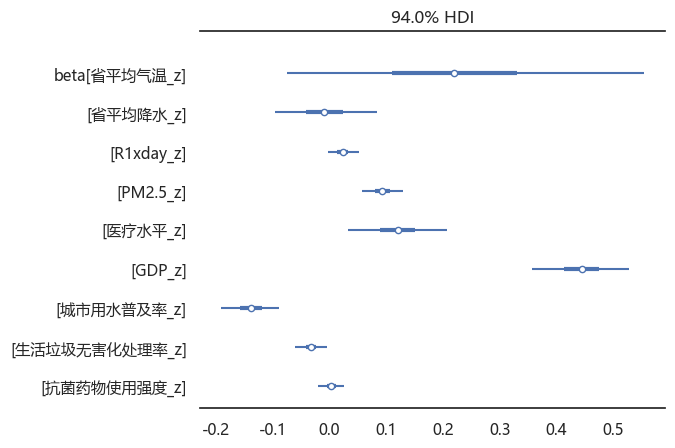

In [33]:
#az.plot_forest(trace, var_names=["beta"])

# 只画一条
az.plot_forest(trace, var_names=["beta"], combined=True)


### **绘制高风险区域地图**
建议用“空间随机效应（structured + unstructured）”的后验均值做风险强度（最贴合空间模型含义）

In [ ]:
# 0) 先确认你 trace 里有什么变量名
import arviz as az
print(az.summary(trace, var_names=None).index[:30])
print(trace.posterior.data_vars)


Index(['alpha', 'beta[省平均气温_z]', 'beta[省平均降水_z]', 'beta[R1xday_z]', 'beta[PM2.5_z]', 'beta[医疗水平_z]', 'beta[GDP_z]', 'beta[城市用水普及率_z]', 'beta[生活垃圾无害化处理率_z]', 'beta[抗菌药物使用强度_z]',
       'gamma_year[0]', 'gamma_year[1]', 'gamma_year[2]', 'gamma_year[3]', 'gamma_year[4]', 'gamma_year[5]', 'gamma_year[6]', 'gamma_year[7]', 'u[0]', 'u[1]', 'u[2]', 'u[3]',
       'u[4]', 'u[5]', 'u[6]', 'u[7]', 'u[8]', 'u[9]', 'u[10]', 'u[11]'],
      dtype='object')
Data variables:
    alpha       (chain, draw) float64 64kB 0.3537 -0.2047 ... -0.2954 -0.2746
    beta        (chain, draw, cov) float64 576kB 0.2874 0.02892 ... 0.02602
    gamma_year  (chain, draw, year) float64 512kB -0.6321 -0.515 ... 0.6537
    u           (chain, draw, prov) float64 2MB 2.989 -1.017 ... 0.09149 0.2449
    s           (chain, draw, prov) float64 2MB 1.025 0.09844 ... 0.5443 -0.1219
    sigma_s     (chain, draw) float64 64kB 0.7068 1.212 0.7156 ... 1.118 0.9123
    rho         (chain, draw) float64 64kB 0.0353 0.5471 ... 0.82

In [39]:
# 1) 高风险区域地图
## 取每个省的空间效应后验均值（risk_score）

import numpy as np
import arviz as az

post0 = trace.posterior
spatial = post0["u"] + post0["s"]          # dims: chain, draw, prov
n_prov_trace = int(spatial.sizes["prov"])  # 30

risk_mean = spatial.mean(dim=("chain","draw")).to_numpy()

hdi_ds = az.hdi(spatial, hdi_prob=0.94)
print("hdi vars:", list(hdi_ds.data_vars))   # 你跑一下就知道变量名

hdi_da = hdi_ds[list(hdi_ds.data_vars)[0]]   # 取出 DataArray
risk_lo = hdi_da.sel(hdi="lower").to_numpy()
risk_hi = hdi_da.sel(hdi="higher").to_numpy()

print("lens:", len(risk_mean), len(risk_lo), len(risk_hi), "n_prov_trace:", n_prov_trace)


hdi vars: ['x']
lens: 30 30 30 n_prov_trace: 30


In [38]:
# ① 先把风险表做出来（risk_df）

import pandas as pd
import numpy as np

# 这里用你建模时的省份顺序（长度=30）
prov_list = list(provinces)   # 或者你自己定义的 prov_list（一定要是模型顺序）

risk_df = pd.DataFrame({
    "Province": prov_list,
    "risk_mean": risk_mean,
    "risk_lo":   risk_lo,
    "risk_hi":   risk_hi,
})

risk_df["risk_width"] = risk_df["risk_hi"] - risk_df["risk_lo"]

# 看看前几行确认
risk_df.head(), risk_df.shape


(  Province  risk_mean   risk_lo   risk_hi  risk_width
 0       上海   3.325993  2.099707  4.625233    2.525527
 1       云南  -0.581856 -1.363163  0.272389    1.635552
 2      内蒙古   0.737587 -0.184717  1.631079    1.815796
 3       北京   3.148691  2.110327  4.282919    2.172592
 4       吉林  -0.370078 -1.242585  0.574245    1.816830,
 (30, 5))

In [57]:
import geopandas as gpd

china = gpd.read_file(r"C:\Users\lunch\Downloads\100000_full.json")
print(china.head())
print("省份数：", china.shape)


Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


   adcode    name adchar  childrenNum     level                parent  subFeatureIndex                                           geometry
0  110000     北京市   None         16.0  province  { "adcode": 100000 }              0.0  MULTIPOLYGON (((117.34861 40.58114, 117.38988 ...
1  120000     天津市   None         16.0  province  { "adcode": 100000 }              1.0  MULTIPOLYGON (((117.7656 39.40053, 117.84691 3...
2  130000     河北省   None         11.0  province  { "adcode": 100000 }              2.0  MULTIPOLYGON (((117.46749 40.64974, 117.41267 ...
3  140000     山西省   None         11.0  province  { "adcode": 100000 }              3.0  MULTIPOLYGON (((110.37926 34.60061, 110.42484 ...
4  150000  内蒙古自治区   None         12.0  province  { "adcode": 100000 }              4.0  POLYGON ((97.1729 42.79526, 97.37124 42.45708,...
省份数： (35, 8)


In [61]:
# --- 省名对齐诊断 ---
def strip_suffix_cn(x: str) -> str:
    if not isinstance(x, str):
        return x
    # 先处理长后缀（必须先做！否则会被“自治区”提前截断）
    for suf in ["维吾尔自治区", "壮族自治区", "回族自治区", "特别行政区"]:
        x = x.replace(suf, "")
    # 再处理短后缀
    for suf in ["自治区", "省", "市"]:
        x = x.replace(suf, "")
    return x

china["Province_norm"] = china["name"].astype(str).map(strip_suffix_cn)
risk_df["Province_norm"] = risk_df["Province"].astype(str).map(strip_suffix_cn)

china_set = set(china["Province_norm"].dropna().unique())
risk_set  = set(risk_df["Province_norm"].dropna().unique())

print("In map but NOT in risk_df:", sorted(china_set - risk_set))
print("In risk_df but NOT in map:", sorted(risk_set - china_set))


In map but NOT in risk_df: ['', '台湾', '澳门', '西藏', '香港']
In risk_df but NOT in map: []


No-data regions in map: ['', '台湾省', '澳门特别行政区', '西藏自治区', '香港特别行政区']


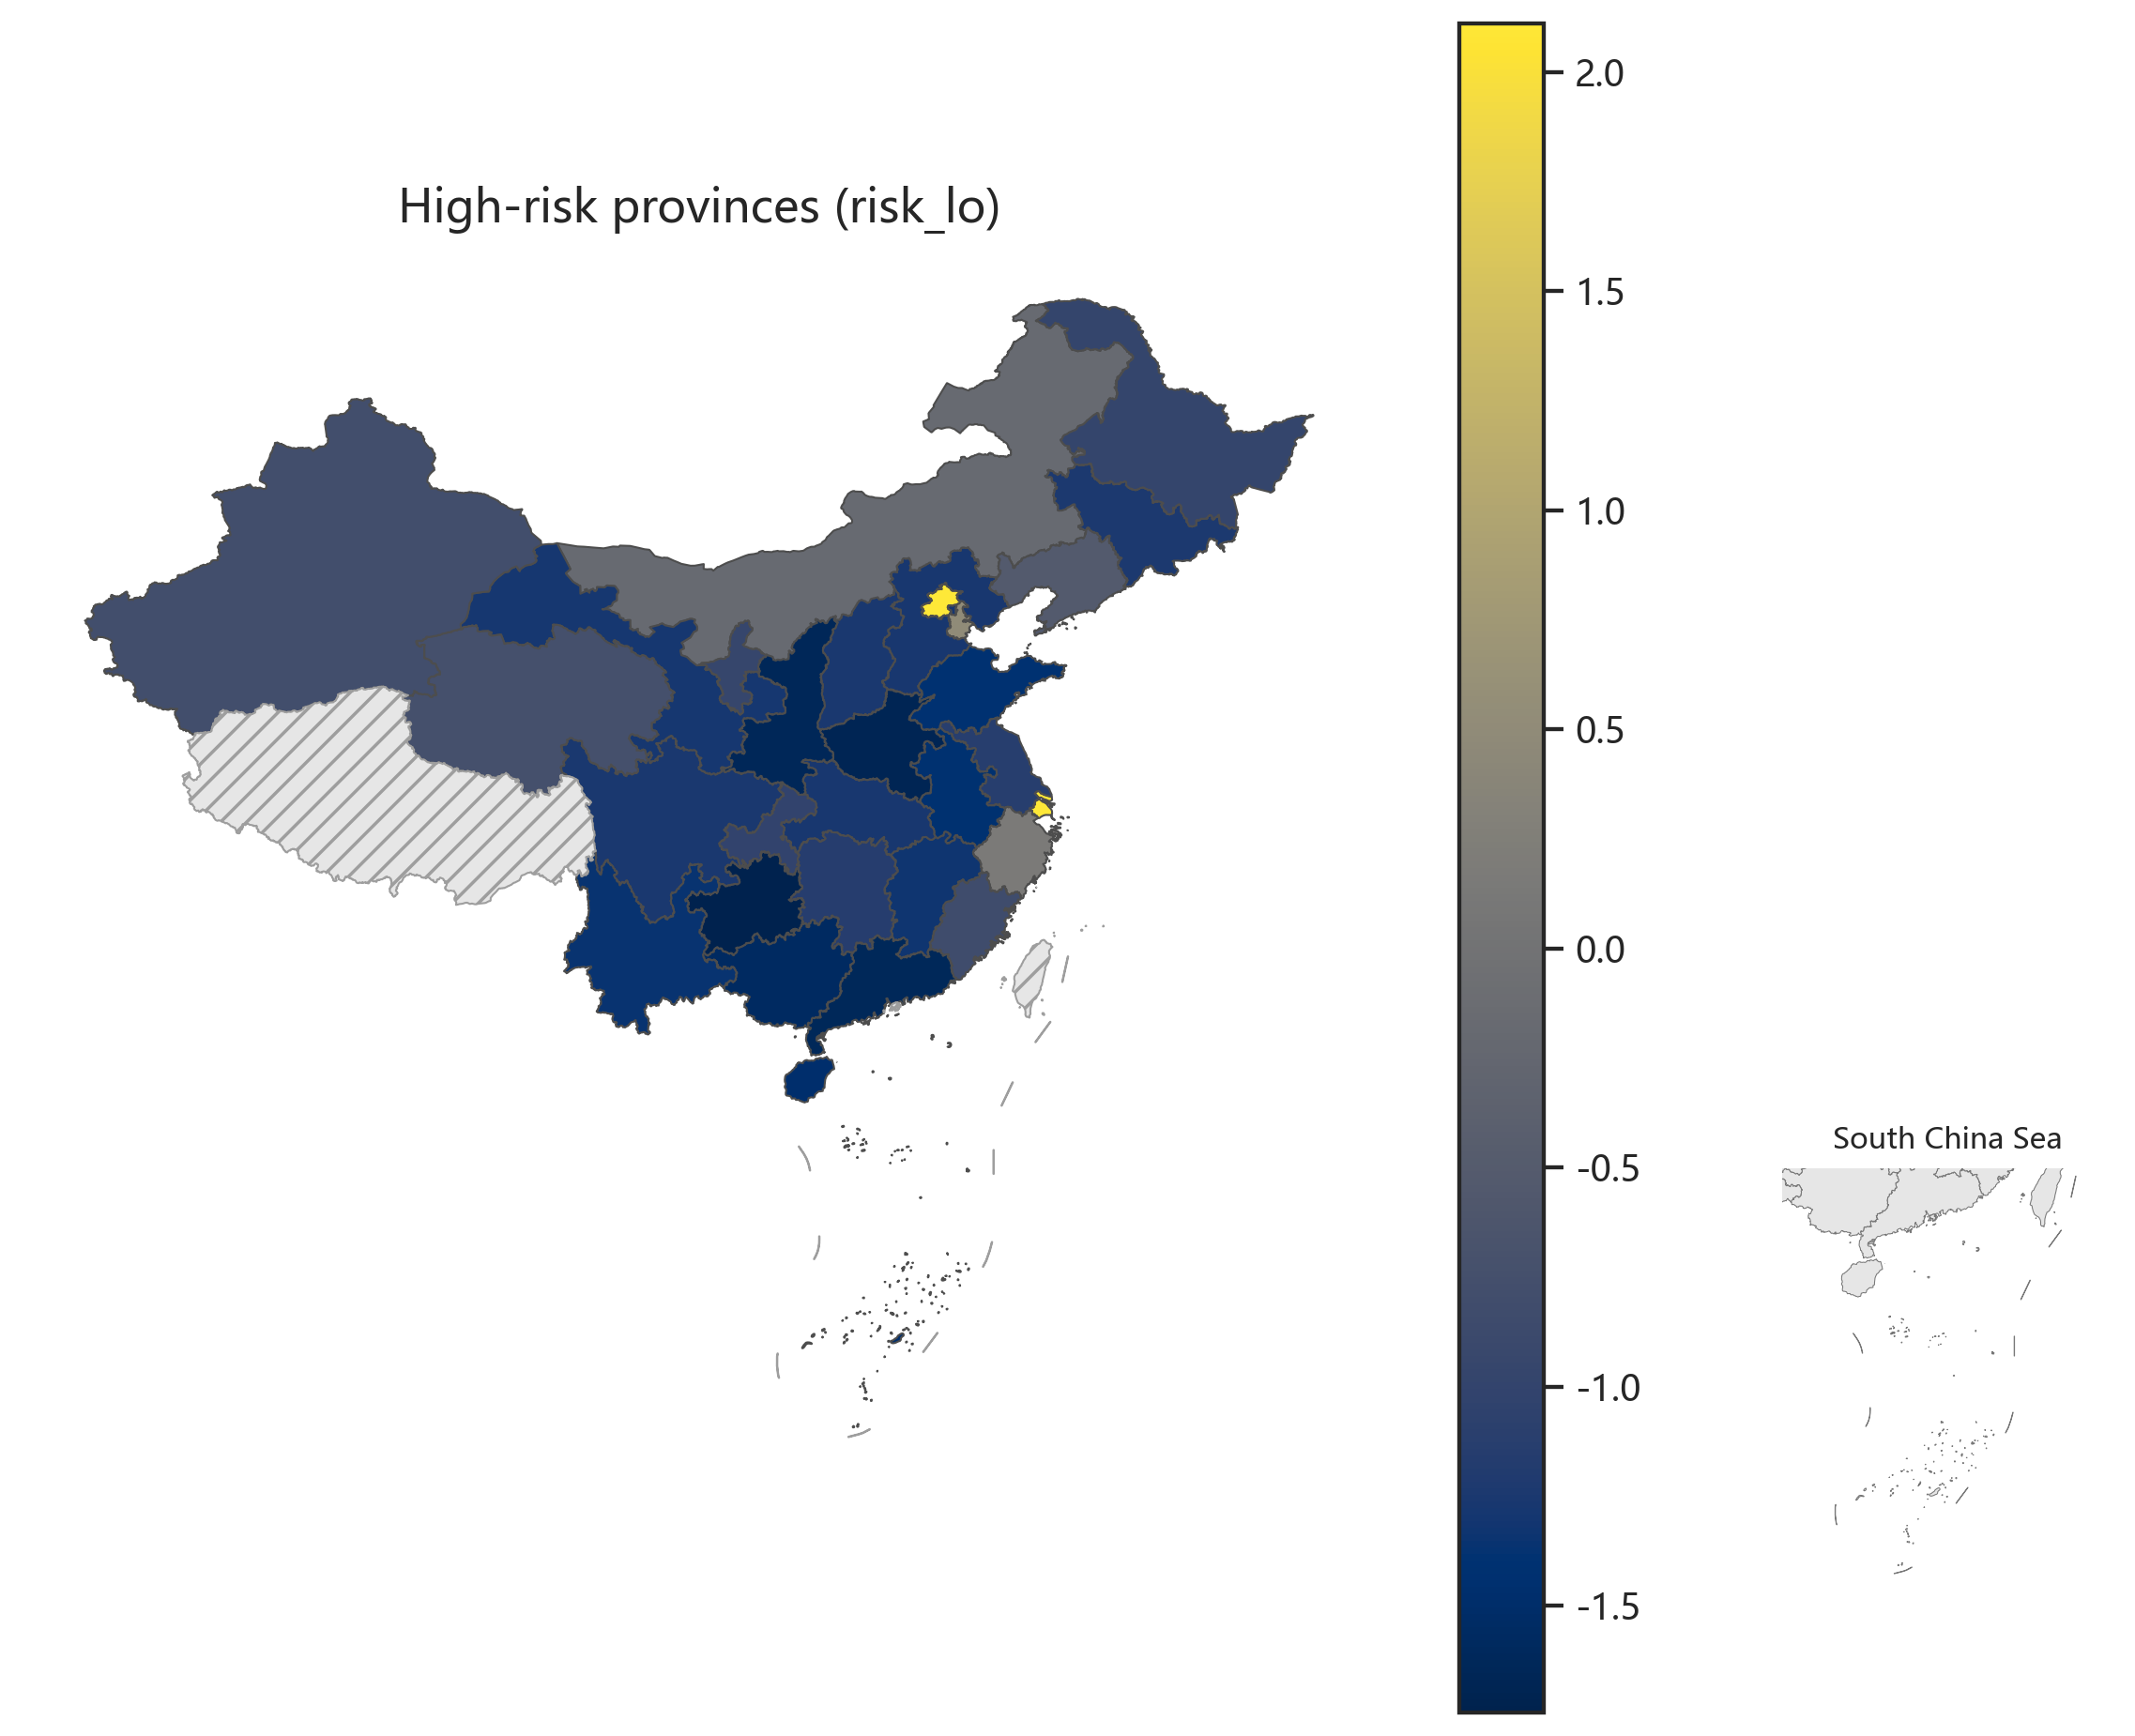

In [63]:
# ② 高风险区域地图（Choropleth）
### 现在 gdf 里可能有重复/多条（比如新疆、西藏出现 Z02/Z03），所以先 按 Province dissolve 合并成一条。

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= 0) 选择画哪个风险列 =========
RISK_COL = "risk_lo"     # 更保守
# RISK_COL = "risk_mean" # 更直观

assert set(["Province", "risk_mean", "risk_lo", "risk_hi"]).issubset(risk_df.columns)

# ========= 1) 省名标准化（关键修复：壮族/回族/维吾尔 等） =========
def strip_suffix_cn(x: str) -> str:
    if not isinstance(x, str):
        return x
    # 先去长后缀
    for suf in ["维吾尔自治区", "壮族自治区", "回族自治区", "特别行政区"]:
        x = x.replace(suf, "")
    # 再去短后缀
    for suf in ["自治区", "省", "市"]:
        x = x.replace(suf, "")
    return x

china = china.copy()
china["Province_norm"] = china["name"].astype(str).map(strip_suffix_cn)

risk_df2 = risk_df.copy()
risk_df2["Province_norm"] = risk_df2["Province"].astype(str).map(strip_suffix_cn)

# ========= 2) merge（港澳台没有数据也保留 -> NaN 灰色） =========
gdf = china.merge(risk_df2[["Province_norm","risk_mean","risk_lo","risk_hi"]],
                  on="Province_norm", how="left")

# 你也可以打印一下哪些省没数据（应该只剩港澳台等）
no_data = sorted(gdf.loc[gdf[RISK_COL].isna(), "name"].astype(str).unique().tolist())
print("No-data regions in map:", no_data)

# ========= 3) 规范南海诸岛：主图不显示太散的点，用 inset 小框展示 =========
# 常见在 DataV：南海诸岛要素 name 里含 “南海诸岛”
island_mask = gdf["name"].astype(str).str.contains("南海", na=False)

main = gdf[~island_mask].copy()
islands = gdf[island_mask].copy()

# ========= 4) 顶刊配色 + 缺失灰色斜线 =========
cmap = "cividis"  # 更“顶刊”、色盲友好、稳重
missing_style = dict(color="#E6E6E6", edgecolor="#9E9E9E", hatch="///", label="No data")

fig = plt.figure(figsize=(10, 8), dpi=250)

# 主图轴
ax = fig.add_axes([0.05, 0.05, 0.72, 0.90])
main.plot(
    ax=ax,
    column=RISK_COL,
    cmap=cmap,
    linewidth=0.6,
    edgecolor="#4D4D4D",
    legend=True,
    missing_kwds=missing_style,
)
ax.set_title(f"High-risk provinces ({RISK_COL})", fontsize=14)
ax.set_axis_off()

# inset（南海诸岛小框）
ax_in = fig.add_axes([0.78, 0.12, 0.18, 0.22])
china.plot(
    ax=ax_in,
    color="#E6E6E6",
    edgecolor="#777777",
    linewidth=0.3
)
ax_in.set_xlim(105, 125)
ax_in.set_ylim(3, 25)
ax_in.set_title("South China Sea", fontsize=9)
ax_in.axis("off")

plt.show()


IndexError: index 29 is out of bounds for axis 0 with size 27

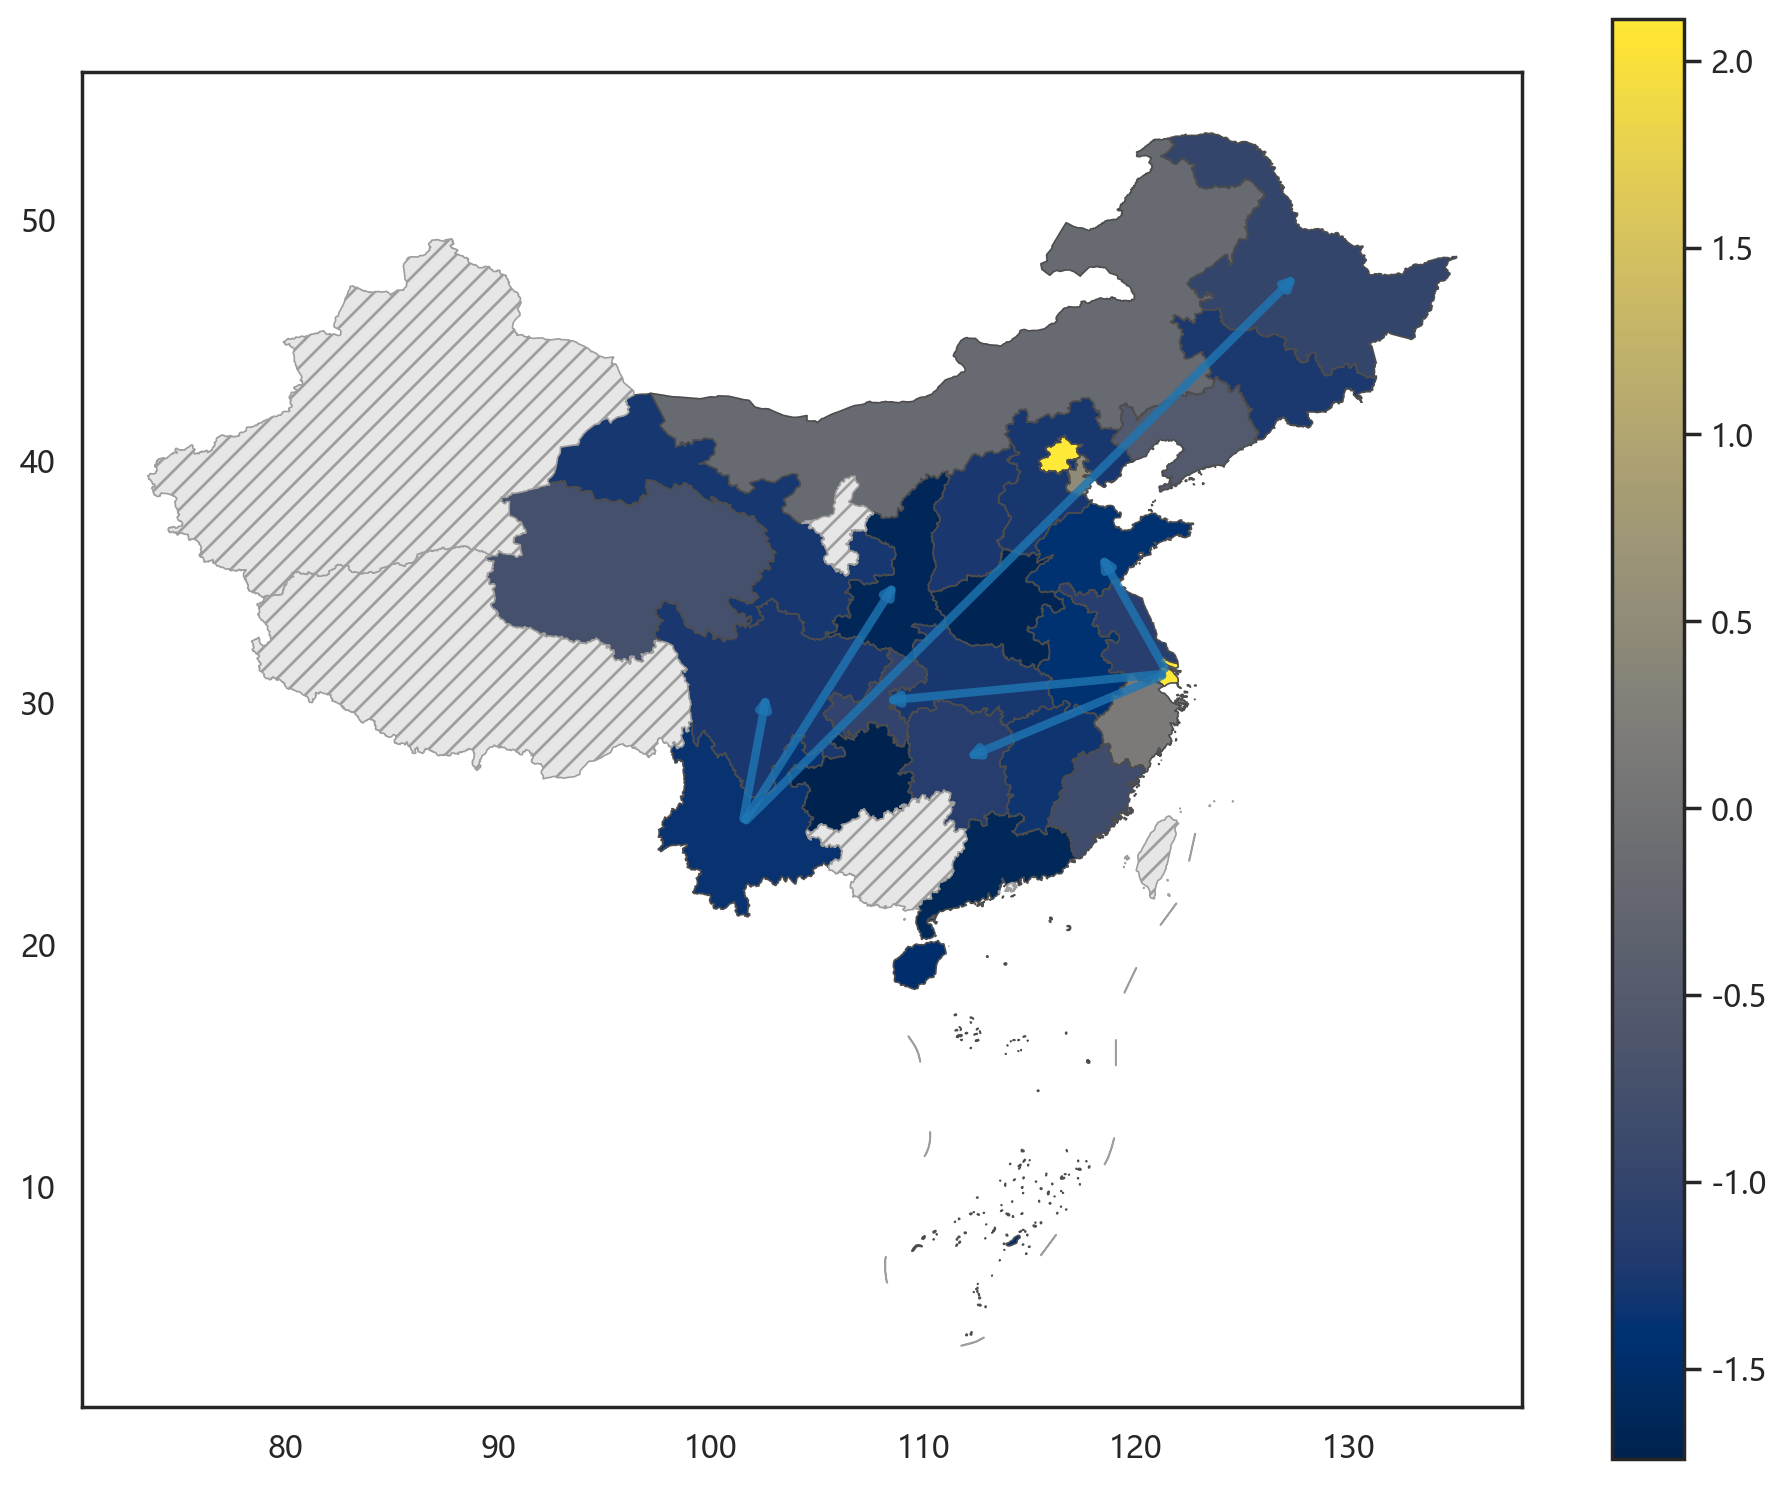

In [60]:
# ③ 省际影响路径
# =========================
# 影响路径图（Wr 边叠加在完整中国底图上）
# 需要你已经有：
# - gdf（上一段 map 代码里生成的，包含 Province + geometry + risk_*）
# - prov_list：Wr 的省份顺序（长度=30），必须与 Wr 行列顺序一致
# - Wr：行标准化后的空间权重矩阵（30x30）
# =========================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

assert "Wr" in globals()
assert "prov_list" in globals()
assert Wr.shape[0] == Wr.shape[1] == len(prov_list), "Wr 与 prov_list 长度必须一致"

# 1) 取 30 省的几何，并按 prov_list 顺序对齐
g30 = gdf[gdf["Province"].isin(prov_list)].copy()
g30["Province"] = pd.Categorical(g30["Province"], categories=prov_list, ordered=True)
g30 = g30.sort_values("Province")

# 2) 质心（用于画箭头）
# 注意：经纬度下 centroid 会有 warning，但这里只是画示意路径，足够用；
# 想更严谨可以先投影到 EPSG:3857 再 centroid。
cent = g30.geometry.centroid
xy = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])

# 3) 选择画哪些边：每个省只画 top_k 条最强“外溢”边
top_k = 3
edges = []
for i in range(Wr.shape[0]):
    w = Wr[i].copy()
    w[i] = 0
    js = np.argsort(w)[::-1][:top_k]
    for j in js:
        if w[j] > 0:
            edges.append((i, j, float(w[j])))

# 4) 画底图（完整中国，缺失灰色），再叠加路径
fig = plt.figure(figsize=(10, 8), dpi=200)
ax = fig.add_axes([0.05, 0.05, 0.90, 0.90])

# 底图：用 risk_lo 或 risk_mean 都行（你自己选）
RISK_COL = "risk_lo"
gdf.plot(
    ax=ax,
    column=RISK_COL,
    cmap="cividis",
    linewidth=0.6,
    edgecolor="#4D4D4D",
    legend=True,
    missing_kwds=dict(color="#E6E6E6", edgecolor="#9E9E9E", hatch="///", label="No data"),
)

# 叠加箭头（权重越大越粗/越深）
w_max = max([w for _, _, w in edges]) if edges else 1.0
for i, j, w in edges:
    x1, y1 = xy[i]
    x2, y2 = xy[j]
    lw = 0.5 + 2.5 * (w / w_max)
    alpha = 0.15 + 0.65 * (w / w_max)
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>',
        mutation_scale=8,
        linewidth=lw,
        color="#1F77B4",
        alpha=alpha,
    )
    ax.add_patch(arrow)

ax.set_title(f"Inter-provincial influence paths (top {top_k} outgoing edges by Wr)", fontsize=14)
ax.set_axis_off()
plt.show()



Wr.shape = (30, 30)


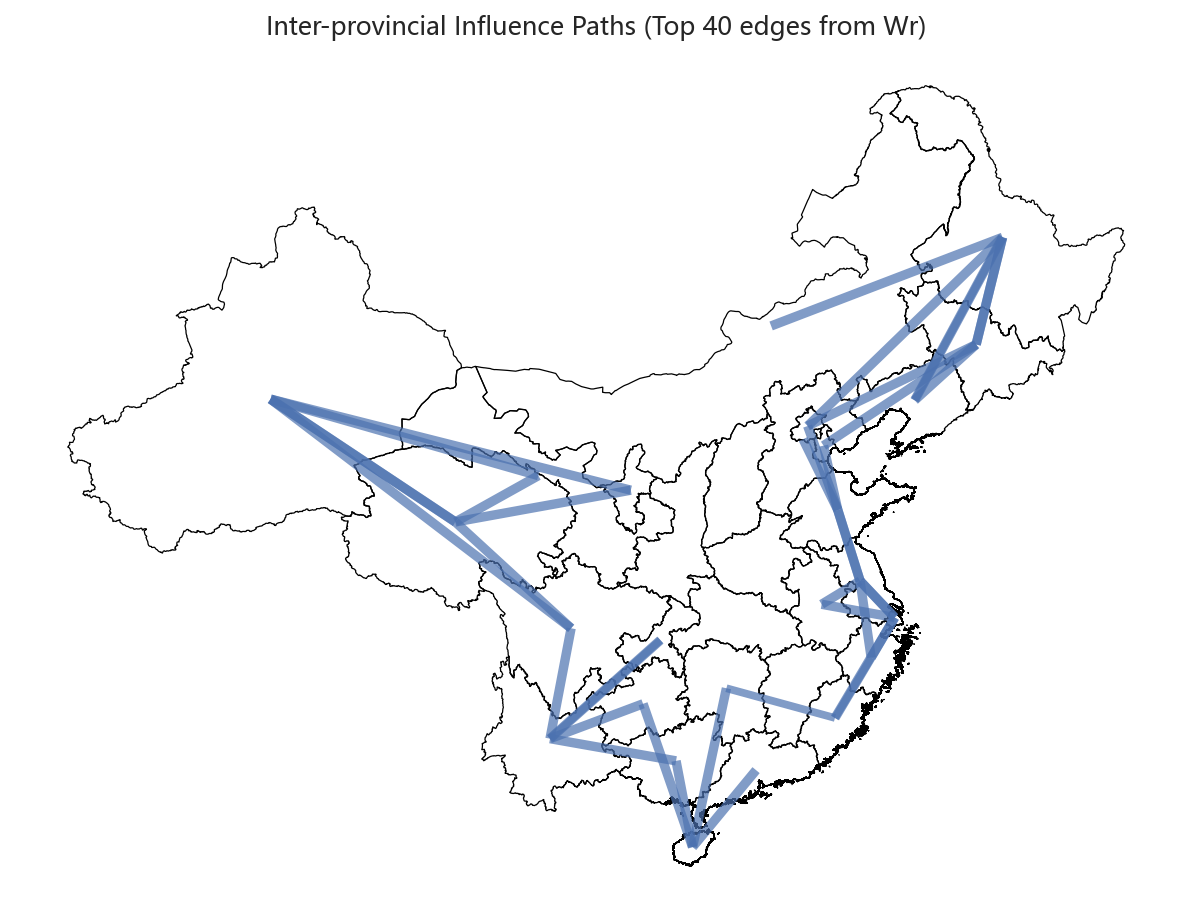

,from,to,w
0,上海,安徽,0.25
1,上海,江苏,0.25
2,上海,浙江,0.25
3,上海,福建,0.25
4,云南,四川,0.25
5,云南,广西,0.25
6,云南,贵州,0.25
7,云南,重庆,0.25
24,吉林,黑龙江,0.25
21,吉林,北京,0.25


In [53]:
# 3.2 抽取 top 边并画“影响路径图”

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Wr: 30x30 (float) 你前面算的行标准化矩阵
n = Wr.shape[0]
assert n == len(prov_list)

# 验证We.shape是不是(30,30)
print("Wr.shape =", Wr.shape)
assert Wr.shape == (30, 30), f"Wr shape wrong: {Wr.shape}"

# 抽边：只取 Wr>0 的边
edges = []
for i in range(n):
    for j in range(n):
        w = Wr[i, j]
        if (i != j) and (w > 0):
            pi = gdf_cent_3857.loc[i, "Province"]
            pj = gdf_cent_3857.loc[j, "Province"]
            ci = gdf_cent_3857.loc[i, "centroid"]
            cj = gdf_cent_3857.loc[j, "centroid"]
            edges.append((pi, pj, w, LineString([ci, cj])))

edges_df = gpd.GeoDataFrame(edges, columns=["from", "to", "w", "geometry"], crs="EPSG:3857")

# 取 top K 边（最强影响路径）
K = 40
edges_top = edges_df.sort_values("w", ascending=False).head(K)

# 画图
fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=150)

# 底图省界
gdf_cent_3857.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.6)

# 路径（线宽按权重）
# 线宽不要太夸张：做一个缩放
lw = 0.5 + 4.0 * (edges_top["w"] / edges_top["w"].max())
edges_top.plot(ax=ax, linewidth=lw, alpha=0.7)

ax.set_title(f"Inter-provincial Influence Paths (Top {K} edges from Wr)")
ax.axis("off")
plt.show()

edges_top[["from", "to", "w"]].head(15)


In [46]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============ 0) 选择画哪一种风险 ============
RISK_COL = "risk_lo"      # 更严格：risk_lo；想直观就 risk_mean
TITLE = "High-risk provinces (Bayesian spatial effect, 94% HDI lower bound)" if RISK_COL=="risk_lo" else "High-risk provinces (Bayesian spatial effect, posterior mean)"

# ============ 1) 左合并：31 省底图 + 30 省风险 ============
# gdf_all: 31省 (Province, geometry)
# risk_df: 30省 (Province, risk_mean, risk_lo, risk_hi)
gdf_map = gdf_all.merge(risk_df, on="Province", how="left")

# 缺失（如西藏）会是 NaN：我们要保留它，画成灰色
print("Total provinces in map:", gdf_map["Province"].nunique())
print("Missing risk provinces:", gdf_map.loc[gdf_map[RISK_COL].isna(), "Province"].tolist())

# ============ 2) 设置颜色（好看 + 缺失灰色） ============
cmap = plt.get_cmap("YlOrRd")
cmap = cmap.copy()
cmap.set_bad(color="#f0f0f0")  # NaN -> 灰色

vals = gdf_map[RISK_COL].to_numpy()
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ============ 3) 主图 ============
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1)

gdf_map.plot(
    column=RISK_COL,
    ax=ax,
    cmap=cmap,
    norm=norm,
    linewidth=0.6,
    edgecolor="#666666",
    missing_kwds={"color": "#f0f0f0", "edgecolor": "#666666", "hatch": "///", "label": "No data"}
)

ax.set_title(TITLE, fontsize=14)
ax.set_axis_off()

# colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label(RISK_COL, fontsize=11)

# ============ 4) 南海诸岛 inset（可选，但你要求必须有） ============
# 方式：读一个带“南海诸岛”的 GeoJSON（DataV/ECharts 的 100000_small.json）
# 你需要先下载到本地，比如：./china_datav/100000_small.json
# （geo.datav 项目说明里有这个文件）: turn7search17

try:
    scs = gpd.read_file("./china_datav/100000_small.json")  # 你把路径改成自己的
    # 通常 feature 名叫 “南海诸岛”，有的文件是全中国+小窗，这里直接画右下角 inset
    ax_in = fig.add_axes([0.72, 0.08, 0.22, 0.22])  # [left, bottom, width, height]

    scs.plot(ax=ax_in, color="#f8f8f8", edgecolor="#444444", linewidth=0.5)
    ax_in.set_axis_off()
    ax_in.set_title("South China Sea", fontsize=9)
except Exception as e:
    print("[WARN] South China Sea inset not plotted:", e)
    print("You can add it by downloading DataV/ECharts GeoJSON with 南海诸岛 (e.g., 100000_small.json).")

plt.show()


NameError: name 'gdf_all' is not defined